# Plot a cable-free run

This notebook plots the output of a WHOI Cable run of a surface mooring, made
with the patched `cable-free`:

- a summary of when the buoy was fully submerged, the tensions, and an anchor estimate
- the surface current, buoy position and tension through time
- the mooring shape, static and at the buoy's deepest point
- the tension along the line
- an animation of the mooring, and one with the line coloured by tension, saved as MP4 files

**Before running it**, run the case in a WSL terminal from the repository folder:

```bash
scripts/run_case.sh southland_front_30m
```

Open this notebook in Jupyter with the **Python (whoi-cable)** kernel
(`scripts/setup_env.sh` registers it; choose it under **Kernel → Change
Kernel** if Jupyter doesn't pick it automatically). Then set `RUN_NAME` in the
next cell and run all cells.

The sea surface is rebuilt from the `x-wave` settings in the `.cbl` file, using
Cable's convention $\eta(x,t) = R(t)\sum_i a_i \cos(k_i x - \omega_i t - \phi_i)$
with $x$ measured from the anchor and $R(t)$ the wave ramp. Only
`input-type = regular` waves can be rebuilt; random seas are drawn flat. The
current is the `x-current` profile times `x-current-modulation(t)`.

**GUI compatibility update (3 October 2026):** accepts quoted and unquoted buoy names, including quoted names containing spaces. Set `RUN_DIR_OVERRIDE` in Settings to the full timestamped GUI run directory; keep `RUN_NAME` as the `.mat`/`.cbl` basename. Existing CLI run folders work with `RUN_DIR_OVERRIDE = None`.


Based on the plotting notebook in the supplied WHOI Cable package. Distributed under GPL-3.0-or-later; see `COPYING` in the complete package.


## Settings

In [5]:
RUN_NAME = "southland_front_30m"  # basename of .mat / .cbl, WITHOUT timestamp
# For a GUI run, enter its full timestamped directory here (a string is fine):
RUN_DIR_OVERRIDE = "/home/smiro41p/whoi_cable/runs/southland_front_30m_20261003_200825_264493"
# Example: RUN_DIR_OVERRIDE = "/home/smiro41p/whoi_cable/runs/southland_front_30m_20261003_195700_591498"

MAKE_ANIMATIONS = True    # mooring animation, and one coloured by tension
SAVE_VIDEOS     = True    # save the animations as MP4 (needs ffmpeg)
SHOW_INLINE     = True    # also show the saved videos in the notebook
PLAY_SPEED      = 5       # 1 = real time
FRAME_STEP      = 1       # use every n-th snapshot (raise to make animations faster to build)

# anchor estimate
MU         = 0.5          # seabed friction coefficient
SF         = 1.5          # safety factor
RHO_ANCHOR = 7850         # anchor material density (kg/m^3): steel 7850, concrete ~2400

## Setup

In [6]:
import os
import re
import shutil
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon
from scipy.io import loadmat
from IPython.display import Video, display

def find_repo(start=Path.cwd()):
    # the repository folder is the first parent containing cases/ and scripts/
    for p in [start, *start.parents]:
        if (p / "cases").is_dir() and (p / "scripts").is_dir():
            return p
    raise FileNotFoundError("Can't find the repository folder; set RUN_DIR by hand.")

if RUN_DIR_OVERRIDE:
    RUN_DIR = Path(RUN_DIR_OVERRIDE).expanduser().resolve()
else:
    REPO_DIR = find_repo()
    RUN_DIR = REPO_DIR / "runs" / RUN_NAME
VIDEO_DIR = RUN_DIR                                                   # where MP4s are written
print("Run folder:", RUN_DIR)

# The kernel may be started by a Jupyter installed in another environment, so
# its PATH may not include this environment's programs: look for ffmpeg here too.
FFMPEG = shutil.which("ffmpeg") or shutil.which("ffmpeg", path=str(Path(sys.prefix) / "bin"))
if FFMPEG:
    plt.rcParams["animation.ffmpeg_path"] = FFMPEG
if "whoi-cable" not in sys.prefix:
    print(f"Note: this kernel runs Python from {sys.prefix}, not the whoi-cable environment.\n"
          "      Choose Kernel -> Change Kernel -> 'Python (whoi-cable)' if anything below fails.")

Run folder: /home/smiro41p/whoi_cable/runs/southland_front_30m_20261003_200825_264493


### Reading the Cable input file

Cable's output doesn't include the buoy shape or the wave and current settings,
so these functions read them from the run's `.cbl` file.

In [7]:
SECTIONS = ["Problem Description", "Analysis Parameters", "Environment", "Buoys",
            "Anchors", "Materials", "Connectors", "Layout", "End"]

def strip_comments(txt):
    txt = re.sub(r"/\*[\s\S]*?\*/", " ", txt)
    return re.sub(r"//[^\n]*", " ", txt)

def section(txt, name):
    """Text of one .cbl section, from its header to the next header."""
    m = re.search(r"(^|\n)\s*" + name + r"\s*\n", txt, re.I)
    if not m:
        raise ValueError(f"Section '{name}' not found")
    rest = txt[m.end():]
    n = re.search(r"\n\s*(" + "|".join(SECTIONS) + r")\s*(\n|$)", rest, re.I)
    return rest[:n.start() + 1] if n else rest

def eval_num(s):
    """Cable allows constant arithmetic such as 36*0.0254."""
    return float(eval(s.strip(), {"__builtins__": {}}, {}))

def read_buoy(cbl_file, name=None):
    """Read quoted/unquoted Cable buoy names and drawable hull geometry."""
    txt = strip_comments(Path(cbl_file).read_text())
    name_pattern = r'(?:"([^"\n]+)"|([A-Za-z_][\w/.:]*))'
    if name is None:
        matches = re.findall(r'\bbuoy\s*=\s*' + name_pattern,
                             section(txt, "Layout"), re.I)
        if not matches:
            raise ValueError("No terminal 'buoy = name' found in the Layout section")
        quoted, unquoted = matches[-1]
        name = quoted or unquoted
    else:
        name = str(name).strip('"')

    blocks, current = {}, None
    for line in section(txt, "Buoys").splitlines():
        m = re.match(r'\s*' + name_pattern, line)
        if m and not re.match(r'\s*=', line[m.end():]):
            current = m.group(1) or m.group(2)
            blocks[current] = line[m.end():]
        elif current is not None:
            blocks[current] += " " + line
    blk = next((b for k, b in blocks.items() if k.casefold() == name.casefold()), None)
    if blk is None:
        raise ValueError(f"Buoy '{name}' not found in Buoys; available: {list(blocks)}")

    m = re.search(r'\btype\s*=\s*(\w+)', blk, re.I)
    btype = m.group(1).lower() if m else "axisymmetric"

    def prop(key):
        aliases = {"d": r"(?:d|diam)", "h": r"(?:h|height)"}
        key_pattern = aliases.get(key, re.escape(key))
        m = re.search(r'(^|\s)' + key_pattern + r'\s*=\s*([^\s=]+)', blk, re.I)
        if not m:
            raise ValueError(f"Buoy '{name}' ({btype}) is missing '{key}'")
        return eval_num(m.group(2))

    if btype == "axisymmetric":
        m = re.search(r'\bdiameters\s*=\s*((\(\s*[^)]*\)\s*,?\s*)+)', blk, re.I)
        if not m:
            raise ValueError(f"Axisymmetric buoy '{name}' has no diameter profile")
        pairs = re.findall(r'\(([^,]+),([^)]+)\)', m.group(1))
        z = np.array([eval_num(a) for a, b in pairs])
        r = np.array([eval_num(b) for a, b in pairs]) / 2
    elif btype == "cylinder":
        D, H = prop("d"), prop("h")
        z, r = np.array([0, H]), np.array([D, D]) / 2
    elif btype == "sphere":
        D = prop("d")
        th = np.linspace(0, np.pi, 41)
        z, r = D / 2 * (1 - np.cos(th)), D / 2 * np.sin(th)
    elif btype == "capsule":
        D, H = prop("d"), prop("h")
        th = np.linspace(0, np.pi / 2, 21)
        zb, rb = D / 2 * (1 - np.cos(th)), D / 2 * np.sin(th)
        z, r = np.r_[zb, H - zb[::-1]], np.r_[rb, rb[::-1]]
    else:
        print(f"Buoy type '{btype}' has no drawable shape; drawn as a dot.")
        z, r = np.array([]), np.array([])
    height = z.max() - z.min() if z.size else 0.0
    return dict(name=name, type=btype, z=z, r=r, height=height)

FUNCS = dict(sin=np.sin, cos=np.cos, tan=np.tan, exp=np.exp, log=np.log, sqrt=np.sqrt,
             fabs=np.abs, abs=np.abs, pow=np.power, pi=np.pi)

def profile_or_expr(s, var):
    """Cable 'discrete expression' (a,b) (c,d) ... -> interpolant;
    otherwise a continuous expression in var (e.g. t) -> function."""
    s = s.strip()
    pairs = re.findall(r"\(([^,()]+),([^,()]+)\)", s)
    if pairs and s.startswith("("):
        xy = np.array([[eval_num(a), eval_num(b)] for a, b in pairs])
        xv, iu = np.unique(xy[:, 0], return_index=True)
        yv = xy[iu, 1]
        if xv.size == 1:
            return lambda q: yv[0] + 0 * np.asarray(q, float)
        return lambda q: np.interp(np.asarray(q, float), xv, yv)
    expr = s.replace("^", "**")
    return lambda q: eval(expr, {"__builtins__": {}}, {**FUNCS, var: np.asarray(q, float)}) + 0 * np.asarray(q, float)

def read_env(cbl_file):
    """Wave, current and ramp settings needed to rebuild the surface and current."""
    txt = strip_comments(Path(cbl_file).read_text())
    num = lambda key, default: (eval_num(m.group(2)) if (m := re.search(
        r"(^|\s)" + key + r"\s*=\s*([-+.\deE*/()]+)", txt, re.I)) else default)
    E = dict(g=num("gravity", 9.81), ramp=num("ramp-time", 0.0))
    m = re.search(r"input-type\s*=\s*(\w+)", txt, re.I)
    E["input_type"] = m.group(1).lower() if m else "regular"
    E["wave"] = np.zeros((0, 3))
    m = re.search(r"x-wave\s*=\s*((\(\s*[^)]*\)\s*)+)", txt, re.I)
    if m:
        E["wave"] = np.array([[eval_num(a), eval_num(b), eval_num(c)]
                              for a, b, c in re.findall(r"\(([^,]+),([^,]+),([^)]+)\)", m.group(1))])
    if E["input_type"] != "regular" and len(E["wave"]):
        print(f"input-type = {E['input_type']}: random seas can't be rebuilt here; surface drawn flat.")
    m = re.search(r"x-current\s*=\s*([^\n]+(\n\s*\([^\n]*)*)", txt, re.I)
    E["U"] = profile_or_expr(m.group(1), "H") if m else (lambda h: 0 * np.asarray(h, float))
    m = re.search(r"x-current-modulation\s*=\s*([^\n]+)", txt, re.I)
    E["mod"] = profile_or_expr(m.group(1), "t") if m else (lambda t: 1 + 0 * np.asarray(t, float))
    return E

def wavenumbers(E, depth):
    k = []
    for a, T, ph in E["wave"]:
        om = 2 * np.pi / T
        kk = om**2 / E["g"]
        for _ in range(100):
            kk = om**2 / (E["g"] * np.tanh(kk * depth))
        k.append(kk)
    return np.array(k)

def surface(E, x, t):
    """Cable's regular-wave surface: ramp(t) * sum a cos(k x - w t - phi)."""
    x, t = np.asarray(x, float), np.asarray(t, float)
    eta = np.zeros(np.broadcast(x, t).shape)
    if E["input_type"] != "regular" or not len(E["wave"]):
        return eta
    ramp = np.minimum(t / E["ramp"], 1) if E["ramp"] > 0 else 1.0
    for (a, T, ph), k in zip(E["wave"], E["k"]):
        eta = eta + a * np.cos(k * x - 2 * np.pi / T * t - ph)
    return ramp * eta

## Load the run

In [8]:
RUN_DIR = Path(RUN_DIR).expanduser()  # also accept a manually assigned string
R = {k: v for k, v in loadmat(RUN_DIR / f"{RUN_NAME}.mat", squeeze_me=True).items()
     if not k.startswith("__")}
cbl_file = RUN_DIR / f"{RUN_NAME}.cbl"
B = read_buoy(cbl_file)
E = read_env(cbl_file)

H      = float(R["depth"])                 # water depth (m)
dt     = float(R["dt"])
snapdt = float(R["snap_dt"])
t      = R["t"]
zs, xs = R["z"] - H, R["x"]                # static line, z = 0 at mean sea level
zb_t   = R["z_t"][:, -1] - H               # buoy base (attachment point)
xb_t   = R["x_t"][:, -1]
zt_t   = zb_t + B["height"]                # buoy top
tsnap  = np.arange(R["z_s"].shape[1]) * snapdt

E["k"] = wavenumbers(E, H)
eta_b  = surface(E, xb_t, t)               # sea surface at the buoy
Usurf  = E["mod"](t) * E["U"](0.0)         # surface current
under  = (zt_t - eta_b) < 0                # buoy fully submerged
draft  = eta_b - zb_t
print(f"Loaded {RUN_NAME}: {len(t)} time steps, {len(tsnap)} snapshots, {len(R['s'])} nodes")

Loaded southland_front_30m: 2101 time steps, 1051 snapshots, 48 nodes


## Summary

In [9]:
print(f'Run "{RUN_NAME}": buoy "{B["name"]}" ({B["type"]}), height {B["height"]:.2f} m, '
      f'static draft {-zs[-1]:.2f} m')
if under.any():
    i1, i2 = np.flatnonzero(under)[[0, -1]]
    print(f"First fully submerged at t = {t[i1]:.1f} s (surface current {Usurf[i1]:.2f} m/s)")
    print(f"Last  fully submerged at t = {t[i2]:.1f} s (surface current {Usurf[i2]:.2f} m/s)")
    print(f"Time fully submerged: {under.sum() * dt:.1f} s of {t[-1] - t[0]:.1f} s")
    idp = np.argmin(zt_t - eta_b)
    print(f"Deepest at t = {t[idp]:.1f} s: buoy top {-(zt_t - eta_b)[idp]:.2f} m below the local surface")
else:
    print(f"Buoy never fully submerged (max draft {draft.max():.2f} m of {B['height']:.2f} m)")
print(f"Max tension: {R['T_t'][:, -1].max() / 1e3:.2f} kN at buoy, {R['T_t'][:, 0].max() / 1e3:.2f} kN at anchor")

# anchor needed: a deadweight anchor holds while its weight in water W' >= V + H/mu
T0, Sn0, phi0 = R["T_t"][:, 0], R["Sn_t"][:, 0], R["phi_t"][:, 0]
Han = T0 * np.sin(phi0) + Sn0 * np.cos(phi0)       # horizontal pull on the anchor (N)
Van = T0 * np.cos(phi0) - Sn0 * np.sin(phi0)       # upward pull on the anchor (N)
need = Van + Han / MU
ia = np.argmax(need)
m_anchor = SF * need[ia] / (9.81 * (1 - 1027 / RHO_ANCHOR))
print(f"\nAnchor: worst at t = {t[ia]:.1f} s (H = {Han[ia]/1e3:.2f} kN, V = {Van[ia]/1e3:.2f} kN), "
      f"mu = {MU}, safety factor {SF}")
print(f"        needs {SF * need[ia] / 1e3:.2f} kN in water = {m_anchor:.0f} kg of material "
      f"with density {RHO_ANCHOR} kg/m^3")

Run "southland_front_30m": buoy "ld1" (axisymmetric), height 0.48 m, static draft 0.10 m
Buoy never fully submerged (max draft 0.23 m of 0.48 m)
Max tension: 0.05 kN at buoy, 0.05 kN at anchor

Anchor: worst at t = 13.8 s (H = 0.05 kN, V = -0.01 kN), mu = 0.5, safety factor 1.5
        needs 0.13 kN in water = 16 kg of material with density 7850 kg/m^3


## Plotting helpers

In [10]:
SEA, BED = "#d9edff", "#8c6640"
BUOY, BUOY_WET = "#ff9933", "#cc5a0d"

def buoy_outline(B, xb, zb, upto=None):
    # closed outline of the body of revolution with its base at (xb, zb), optionally cut at height upto
    z, r = B["z"], B["r"]
    if upto is not None and upto < z[-1]:
        k = np.searchsorted(z, upto)
        rw = np.interp(upto, z, r)
        z, r = np.r_[z[:k], upto], np.r_[r[:k], rw]
    return np.c_[np.r_[xb + r, xb - r[::-1]], np.r_[zb + z, zb + z[::-1]]]

def draw_buoy(ax, B, xb, zb, eta=0.0):
    # buoy with the part below the local sea surface eta shaded darker
    if not B["z"].size:
        ax.plot(xb, zb, "o", mfc=BUOY, mec="k", ms=9); return
    ax.add_patch(Polygon(buoy_outline(B, xb, zb), fc=BUOY, ec="k", lw=1, zorder=5))
    wl = eta - zb                                    # waterline height above the base
    if wl > B["z"][0]:
        ax.add_patch(Polygon(buoy_outline(B, xb, zb, min(wl, B["z"][-1])), fc=BUOY_WET, ec="k", lw=1, zorder=6))

def shade(ax, t, mask, color="0.9"):
    # shade the time intervals where mask is true
    d = np.diff(np.r_[0, mask.astype(int), 0])
    for a, b in zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1) - 1):
        ax.axvspan(t[a], t[b], color=color, zorder=0, lw=0)

## Current, buoy position and tension through time
Grey bands mark when the buoy is fully submerged.

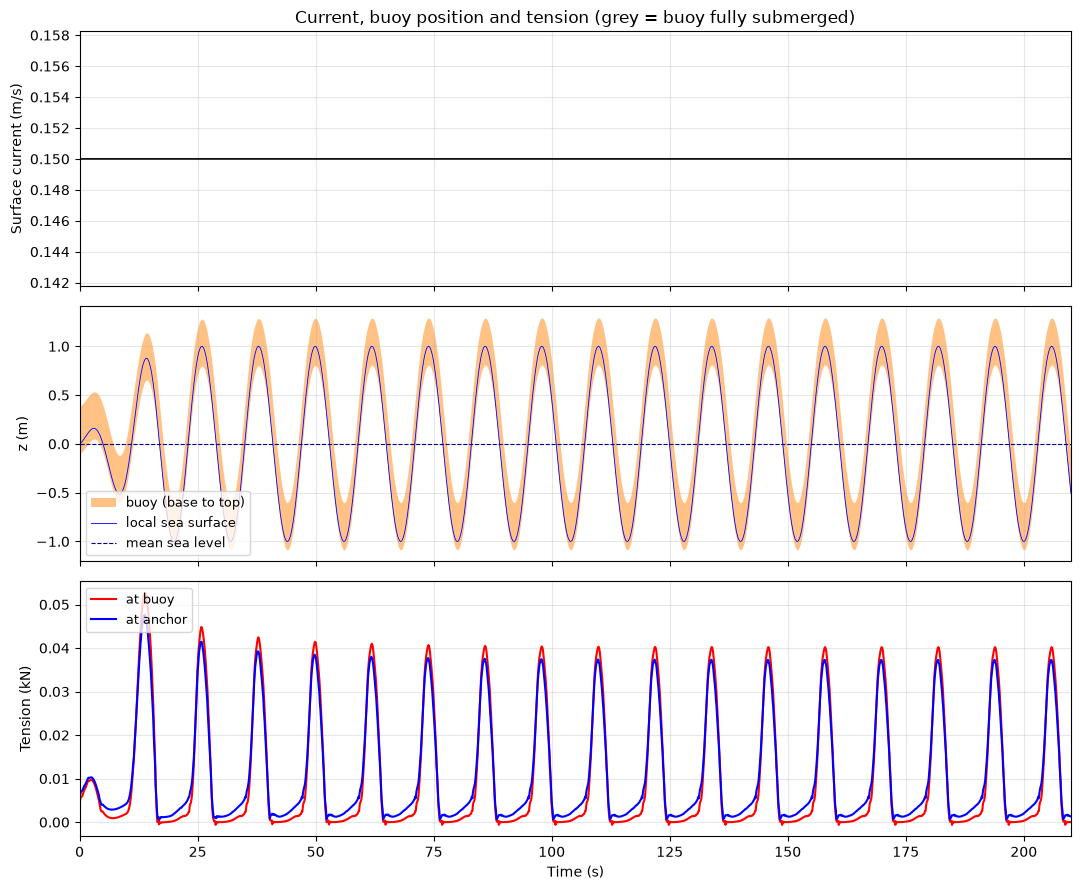

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axs[0].plot(t, Usurf, "k", lw=1.2)
axs[0].set_ylabel("Surface current (m/s)")
axs[0].set_title("Current, buoy position and tension (grey = buoy fully submerged)")

axs[1].fill_between(t, zb_t, zt_t, color=BUOY, alpha=0.6, lw=0, label="buoy (base to top)")
axs[1].plot(t, eta_b, "b", lw=0.6, label="local sea surface")
axs[1].axhline(0, color="navy", ls="--", lw=0.8, label="mean sea level")
axs[1].set_ylabel("z (m)")
axs[1].legend(loc="lower left", fontsize=9)

axs[2].plot(t, R["T_t"][:, -1] / 1e3, "r", label="at buoy")
axs[2].plot(t, R["T_t"][:, 0] / 1e3, "b", label="at anchor")
axs[2].set_ylabel("Tension (kN)"); axs[2].set_xlabel("Time (s)")
axs[2].legend(loc="upper left", fontsize=9)
for ax in axs:
    shade(ax, t, under); ax.grid(alpha=0.3)
axs[2].set_xlim(t[0], t[-1])
plt.tight_layout(); plt.show()

## Mooring shape
Static shape (black), snapshots through the run (grey), and the snapshot with the buoy deepest (red).

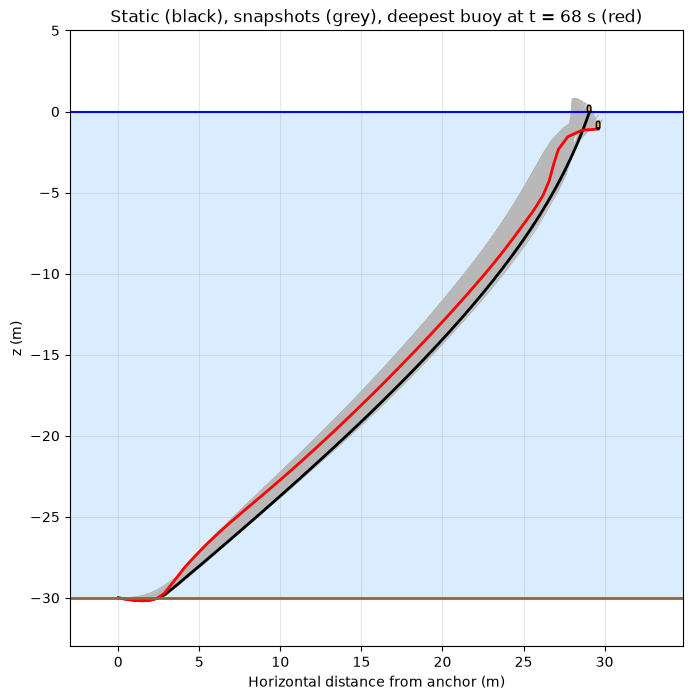

In [12]:
kdeep = np.argmin(R["z_s"][-1, :])
xl = (R["x_s"].min() - 3, R["x_s"].max() + 5)
fig, ax = plt.subplots(figsize=(9, 8))
ax.axhspan(-H, 0, color=SEA, zorder=0)
kplot = np.unique(np.round(np.linspace(0, R["z_s"].shape[1] - 1, min(200, R["z_s"].shape[1]))).astype(int))
ax.plot(R["x_s"][:, kplot], R["z_s"][:, kplot] - H, color="0.72", lw=0.8)
ax.plot(xs, zs, "k", lw=2)
ax.plot(R["x_s"][:, kdeep], R["z_s"][:, kdeep] - H, "r", lw=2)
draw_buoy(ax, B, xs[-1], zs[-1], 0.0)
draw_buoy(ax, B, R["x_s"][-1, kdeep], R["z_s"][-1, kdeep] - H, surface(E, R["x_s"][-1, kdeep], tsnap[kdeep]))
ax.axhline(0, color="b"); ax.axhline(-H, color=BED, lw=2)
ax.set_aspect("equal"); ax.set_xlim(xl); ax.set_ylim(-H - 3, 5); ax.grid(alpha=0.3)
ax.set_xlabel("Horizontal distance from anchor (m)"); ax.set_ylabel("z (m)")
ax.set_title(f"Static (black), snapshots (grey), deepest buoy at t = {tsnap[kdeep]:.0f} s (red)")
plt.show()

## Tension along the line

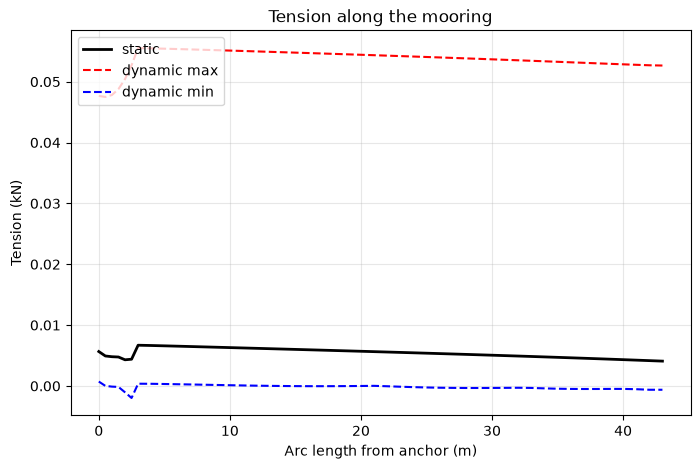

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(R["s"], R["T"] / 1e3, "k", lw=2, label="static")
ax.plot(R["s"], R["T_s"].max(axis=1) / 1e3, "r--", label="dynamic max")
ax.plot(R["s"], R["T_s"].min(axis=1) / 1e3, "b--", label="dynamic min")
ax.set_xlabel("Arc length from anchor (m)"); ax.set_ylabel("Tension (kN)")
ax.set_title("Tension along the mooring"); ax.grid(alpha=0.3); ax.legend(loc="upper left")
plt.show()

## Animations

The first animation shows the mooring moving through the run; the second
colours the line by tension, on one colour scale for the whole run. Building
them takes a while for long runs: raise `FRAME_STEP` in the settings to use
fewer snapshots (a 210 s run with all 1051 snapshots takes a few minutes).
The MP4s are saved in the run folder and shown below.

In [14]:
def animate(by_tension, filename):
    frames = np.arange(0, len(tsnap), FRAME_STEP)
    xl = (R["x_s"].min() - 3, R["x_s"].max() + 5)
    xg = np.linspace(*xl, 400)
    fig, ax = plt.subplots(figsize=(9, 8.2), dpi=100)          # 900 x 820 pixels (even, for H.264)
    if by_tension:
        tlim = max(R["T_s"].max() / 1e3, 1e-3)
        norm = plt.Normalize(0, tlim)
        cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, shrink=0.8)
        cbar.set_label("Tension (kN)")

    def draw(k):
        ax.clear()
        tk = tsnap[k]
        eta = surface(E, xg, tk)
        xk, zk = R["x_s"][:, k], R["z_s"][:, k] - H
        ax.fill_between(xg, -H, eta, color=SEA, lw=0)
        ax.plot(xs, zs, ":", color="0.5")
        if by_tension:
            seg = np.stack([np.c_[xk[:-1], zk[:-1]], np.c_[xk[1:], zk[1:]]], axis=1)
            Tk = R["T_s"][:, k] / 1e3
            lc = LineCollection(seg, cmap="viridis", norm=norm, lw=4)
            lc.set_array(0.5 * (Tk[:-1] + Tk[1:]))              # tension in each element
            ax.add_collection(lc)
            iT = np.argmax(Tk)
            title = (f"t = {tk:5.1f} s   current = {E['mod'](tk) * E['U'](0.0):.2f} m/s   "
                     f"max tension {Tk[iT]:.2f} kN at {R['s'][iT]:.0f} m along line")
        else:
            ax.plot(xk, zk, "k", lw=1.5)
            title = f"t = {tk:5.1f} s   surface current = {E['mod'](tk) * E['U'](0.0):.2f} m/s"
        draw_buoy(ax, B, xk[-1], zk[-1], surface(E, xk[-1], tk))
        ax.plot(xg, eta, "b", lw=1)
        ax.axhline(-H, color=BED, lw=2)
        ax.set_aspect("equal"); ax.set_xlim(xl); ax.set_ylim(-H - 3, 5); ax.grid(alpha=0.3)
        ax.set_xlabel("Horizontal distance from anchor (m)"); ax.set_ylabel("z (m)")
        ax.set_title(title, fontsize=10)

    anim = animation.FuncAnimation(fig, draw, frames=frames, interval=1000 * snapdt * FRAME_STEP / PLAY_SPEED)
    out = None
    if SAVE_VIDEOS:
        if FFMPEG:
            out = VIDEO_DIR / filename
            fps = max(1, round(PLAY_SPEED / (snapdt * FRAME_STEP)))
            anim.save(out, writer=animation.FFMpegWriter(fps=fps, bitrate=3000))
            print("Video written to", out)
        else:
            print("ffmpeg not found, so no video saved. Rerun scripts/setup_env.sh to install it.")
    plt.close(fig)
    return out

if MAKE_ANIMATIONS:
    videos = [animate(False, f"{RUN_NAME}_animation.mp4")]
    if SHOW_INLINE:
        for v in videos:
            if v is not None:
                # linked, not embedded, so the notebook stays small; the files are in the run folder
                display(Video(os.path.relpath(v, Path.cwd()), width=640))

Video written to /home/smiro41p/whoi_cable/runs/southland_front_30m_20261003_200825_264493/southland_front_30m_animation.mp4
